**Overview**

This notebook provides a reproducible example of part of the workflow used in *Heat stress conditions in southern South America: characterization and long-term changes under observational uncertainty* 

The example illustrates:

(1) loading daily ERA5 data from the climate4R repository,

(2) deriving specific humidity (SH) and relative humidity (RH),

(3) calculating selected heat stress indices,

(4) estimating P90 and P99 thresholds for the 1991--2020 baseline period,

(5) computing annual aggregates and linear trends.

To keep the example computationally light, the analysis is restricted to a small region near Porto Alegre and to the warm season (DJF).

In [2]:
options(java.parameters = "-Xmx64g")

library(HeatStress)
library(loadeR)
library(transformeR)
library(visualizeR)
library(RColorBrewer)
library(Kendall)
library(trend)
library(convertR)
library(magrittr)
source("functions_humidity.R")

HeatStress version 1.0.8.1 (2025-08-13) is loaded

Use 'indexShow()' for an overview of the available heat indices

Loading required package: rJava

Loading required package: loadeR.java

Java version 23x amd64 by N/A detected

The maximum JVM heap space available is: 64.00 GB

NetCDF Java Library Version: 4.6.0-SNAPSHOT (Built-On: 20150423.1338) loaded and ready

You can manually set the NetCDF Java Library version before loading the package:
options(loadeR.java_forced_version = "X.Y.Z")
library(loadeR.java)

netCDF-Java CLASSPATH from bundled java package directory: /nfs/home/gmeteo/balmacedar/micromamba/envs/deep-fwi/lib/R/library/loadeR.java/java:/nfs/home/gmeteo/balmacedar/micromamba/envs/deep-fwi/lib/R/library/loadeR.java/java/netcdfAll-4.6.0-SNAPSHOT.jar

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.4 (2025-08-07) is loaded

Please use 'citation("loade


    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.2.2 (2023-10-26) is loaded


Get the latest stable version (2.2.5) using <devtools::install_github('SantanderMetGroup/transformeR')>

Please see 'citation("transformeR")' to cite this package.

visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.

Loading required package: udunits2

udunits system database read from /nfs/home/gmeteo/balmacedar/micromamba/envs/deep-fwi/lib/R/library/udunits2/share/udunits2.xml

convertR version 0.2.1 (2023-06-22) is loaded

  More information about the 'climate4R' ecosystem in: http://meteo.unican.es/climate4R


Attaching package: ‘convertR’


The following objects are masked from ‘package:loadeR’:

    hurs2huss, huss2hurs, tdps2hurs




**Helper functions**

In [ ]:
fP90 <- function(x) {
  as.numeric(quantile(x, probs = 0.90, na.rm = TRUE))
}

fP99 <- function(x) {
  as.numeric(quantile(x, probs = 0.99, na.rm = TRUE))
}

my.sum <- function(x) ifelse( !all(is.na(x)), sum(x, na.rm=T), NA)

calc_index <- function(tas_grid, hurs_grid, fun) {
  tas  <- as.vector(tas_grid$Data)
  hurs <- as.vector(hurs_grid$Data)

  out_vals <- fun(tas, hurs = hurs)
  
  out <- hurs_grid
  out$Data <- array(out_vals, dim = dim(hurs_grid$Data))
  attributes(out$Data) <- attributes(tas_grid$Data)

  out
}

calc_swbgt     <- function(tas, hurs) calc_index(tas, hurs, swbgt)
calc_wbt       <- function(tas, hurs) calc_index(tas, hurs, wbt.Stull)
calc_hi        <- function(tas, hurs) calc_index(tas, hurs, hi)
calc_humidex   <- function(tas, hurs) calc_index(tas, hurs, humidex)
calc_discomInd <- function(tas, hurs) calc_index(tas, hurs, discomInd)

make_exceedance_P90 <- function(idx_DJF, idx_P90) {
  X <- idx_DJF$Data
  P <- idx_P90$Data[1, , ]

  nt <- dim(X)[1]
  out <- array(NA, dim = dim(X))

  for (t in seq_len(nt)) {
    Xt <- X[t, , ]
    out[t, , ] <- ifelse(is.na(Xt), NA, as.numeric(Xt > P))
  }

  res <- idx_DJF
  res$Data <- out
  attributes(res$Data) <- attributes(idx_DJF$Data)
  res
}

trend_fun <- function(x, dates) {

  time <- seq_along(x)

  ok <- is.finite(x)

  if (sum(ok) < 3) return(NA_real_)

  slope <- coef(lm(x[ok] ~ time[ok]))[2]

  return(as.numeric(slope))
}

trend.1D <- function(ts, dates, method = c("pearson","spearman","kendall"),
                     return.pvalue = FALSE, conf.level = 0.95) {
    if (length(dates) != length(ts)) stop("Input and date vector sizes do not match")
    method <- match.arg(method, c("pearson","spearman","kendall"))
    x <- as.numeric(as.Date(dates))
    i <- ifelse(return.pvalue, "p.value", "estimate")
    tryCatch(cor.test(x = ts, y = x, method = method, conf.level = conf.level)[[i]],
             error = function(err) NA)
}

In [4]:
head(ls())

[1] "calc_discomInd" "calc_hi"        "calc_humidex"   "calc_index"    
[5] "calc_swbgt"     "calc_wbt"

**Data access**

ERA5 daily data are accessed from the climate4R repository.
Only a small region near Porto Alegre is used here to provide a lightweight example.

In [ ]:
df  <- read.csv("https://data.meteo.unican.es/inventory.csv")
sub <- subset(df, activity == "ERA5")
inv <- dataInventory(as.character(sub$location))

d2m <- loadGridData(
  as.character(sub$location),
  var = "d2m",
  years = 1982:2022,
  lonLim = c(-51.25, -51),
  latLim = c(-30, -31),
  season = c(12, 1, 2)
)

t2max <- loadGridData(
  as.character(sub$location),
  var = "t2mx",
  years = 1982:2022,
  lonLim = c(-51.25, -51),
  latLim = c(-30, -31),
  season = c(12, 1, 2)
)

sp <- loadGridData(
  as.character(sub$location),
  var = "sp",
  years = 1982:2022,
  lonLim = c(-51.25, -51),
  latLim = c(-30, -31),
  season = c(12, 1, 2)
)
 #save(d2m, t2max, sp, file = "data/era5_example_objects.rda")
#or the complete domain is in data/era5_example_objects.RData

[2026-08-07 14:24:01.609911] Doing inventory ...

[2026-08-07 14:24:06.299513] Opening dataset...

[2026-08-07 14:24:31.028517] The dataset was successfuly opened

[2026-08-07 14:24:51.559616] Retrieving info for 'd2m' (36 vars remaining)

[2026-08-07 14:24:51.592199] Retrieving info for 'e' (35 vars remaining)

[2026-08-07 14:24:51.640046] Retrieving info for 'hurs' (34 vars remaining)

[2026-08-07 14:24:51.673575] Retrieving info for 'huss' (33 vars remaining)

[2026-08-07 14:24:51.708505] Retrieving info for 'msl' (32 vars remaining)

[2026-08-07 14:24:51.749608] Retrieving info for 'q1000' (31 vars remaining)

[2026-08-07 14:24:51.78334] Retrieving info for 'q250' (30 vars remaining)

[2026-08-07 14:24:51.825253] Retrieving info for 'q500' (29 vars remaining)

[2026-08-07 14:24:51.857218] Retrieving info for 'q700' (28 vars remaining)

[2026-08-07 14:24:51.899531] Retrieving info for 'q850' (27 vars remaining)

[2026-08-07 14:24:51.931706] Retrieving info for 'sfcwind' (26 vars rem

In [5]:
load('era5_example_objects.rda')

**Humidity variables**

Specific humidity (SH) is estimated from dew point temperature and surface pressure using the Bohren formulation. Relative humidity (RH) is then derived from SH, air temperature, and pressure.


In [6]:
SH <- tdps2huss(tdps = d2m, ps = sp, formula = "bohren")
RH <- huss2hurs(huss = SH, tas = t2max, ps = sp)

t2max <- gridArithmetics(t2max, 273, operator = "-")
gc()

[2026-08-07 16:01:53.537506] Converting tdps units ...

[2026-08-07 16:02:03.178752] Calculating specific humidity from dew point ...

[2026-08-07 16:02:19.150345] Done.

[2026-08-07 16:02:28.699507] Calculating Relative humidity ...

[2026-08-07 16:02:59.608334] Done.



,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1452695,77.6,2485415,132.8,2485415,132.8
Vcells,443425319,3383.1,1448015598,11047.5,1810019497,13809.4


[2026-08-07 16:06:31.702907] - Computing climatology...

[2026-08-07 16:06:33.514831] - Done.



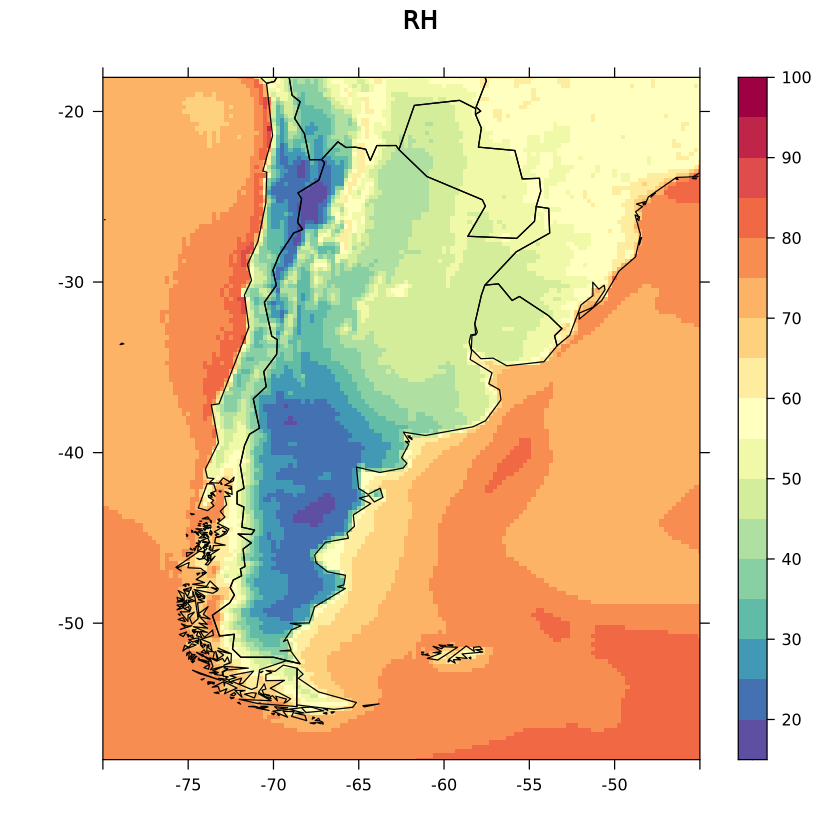

In [16]:
spatialPlot(climatology(RH),color.theme = "Spectral",set.max=100,set.min = 15,
            at=seq(15,100,5),
            scales = list(draw = TRUE),backdrop.theme = 'countries',
            main= "RH",rev.colors = T,xlim=c(-80,-45),ylim=c(-58,-18))

**Heat stress indices**

In [17]:
swbgt_DJF     <- calc_swbgt(t2max, RH)
humidex_DJF   <- calc_humidex(t2max, RH)
hi_DJF        <- calc_hi(t2max, RH)
discomInd_DJF <- calc_discomInd(t2max, RH)
wbt_DJF       <- calc_wbt(t2max, RH)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1673164,89.4,5367605,286.7,5367605,286.7
Vcells,884903246,6751.3,1737698717,13257.6,1810019497,13809.4


**Percentile thresholds (1991--2020)**

In [18]:
swbgt_P90     <- climatology(subsetGrid(swbgt_DJF, years = 1991:2020), clim.fun = list(FUN = "fP90"))
swbgt_P99     <- climatology(subsetGrid(swbgt_DJF, years = 1991:2020), clim.fun = list(FUN = "fP99"))

wbt_P90       <- climatology(subsetGrid(wbt_DJF, years = 1991:2020), clim.fun = list(FUN = "fP90"))
wbt_P99       <- climatology(subsetGrid(wbt_DJF, years = 1991:2020), clim.fun = list(FUN = "fP99"))

[2026-08-07 16:08:13.378156] - Computing climatology...

[2026-08-07 16:08:17.857127] - Done.

[2026-08-07 16:08:22.47653] - Computing climatology...

[2026-08-07 16:08:26.71199] - Done.

[2026-08-07 16:08:31.311291] - Computing climatology...

[2026-08-07 16:08:35.711551] - Done.

[2026-08-07 16:08:40.46483] - Computing climatology...

[2026-08-07 16:08:44.513413] - Done.



**Example: P90 exceedance counts**

In [39]:
datos_P90_wbt   <- make_exceedance_P90(wbt_DJF, wbt_P90)
nro_dias_P90_wbt <- aggregateGrid(datos_P90_wbt, aggr.y = list(FUN = my.sum))

dim(nro_dias_P90_wbt$Data)


[2026-03-17 13:05:17.583661] Performing annual aggregation...

[2026-03-17 13:05:26.392059] Done.



[1]  41 169 141

pad applied on the interval: year



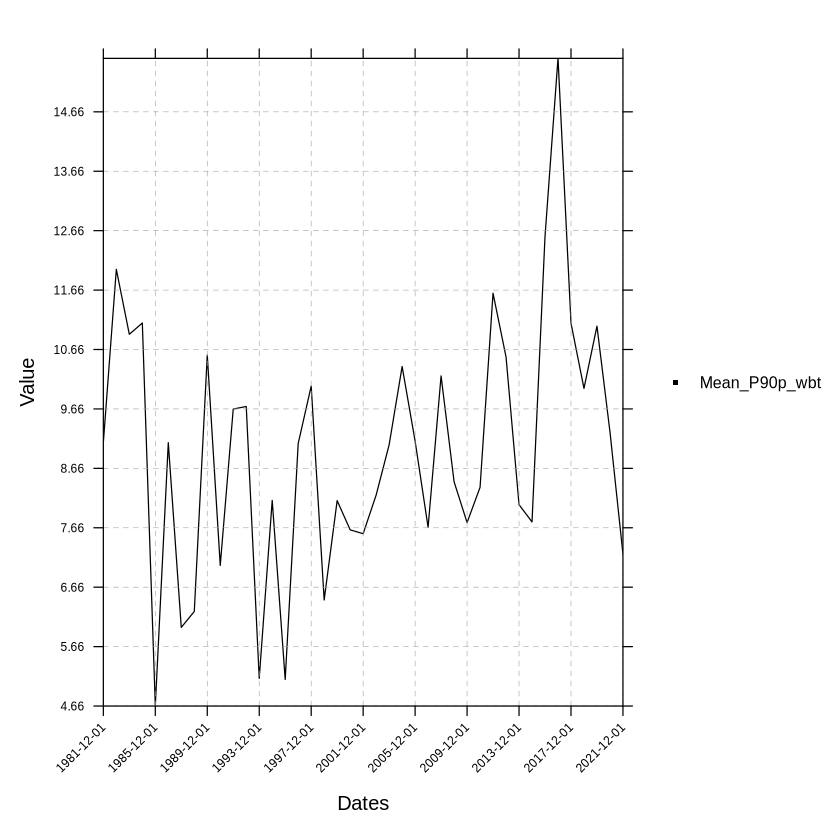

In [42]:
temporalPlot('Mean_P90p_wbt'=nro_dias_P90_wbt)

**Seasonal annual means**

In [19]:
TX_DFJ_y <- aggregateGrid(t2max,     aggr.y = list(FUN = "mean", na.rm = TRUE))
RH_DFJ_y <- aggregateGrid(RH,        aggr.y = list(FUN = "mean", na.rm = TRUE))
SH_DFJ_y <- aggregateGrid(SH,        aggr.y = list(FUN = "mean", na.rm = TRUE))
swbgt_y  <- aggregateGrid(swbgt_DJF, aggr.y = list(FUN = "mean", na.rm = TRUE))
wbt_y    <- aggregateGrid(wbt_DJF,   aggr.y = list(FUN = "mean", na.rm = TRUE))

gc()


[2026-08-07 16:12:08.008053] Performing annual aggregation...

[2026-08-07 16:12:16.888215] Done.

[2026-08-07 16:12:17.557978] Performing annual aggregation...

[2026-08-07 16:12:26.661515] Done.

[2026-08-07 16:12:27.459147] Performing annual aggregation...

[2026-08-07 16:12:36.482787] Done.

[2026-08-07 16:12:36.93969] Performing annual aggregation...

[2026-08-07 16:12:46.665269] Done.

[2026-08-07 16:12:47.119071] Performing annual aggregation...

[2026-08-07 16:12:56.970645] Done.



,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1680001,89.8,5367605,286.7,5367605,286.7
Vcells,889898973,6789.4,1737698717,13257.6,1810019497,13809.4


**Trend estimation**
Linear trends are estimated from the annual DJF means, and Mann--Kendall is used to assess significance.

In [22]:
dates <- getRefDates(TX_DFJ_y)
pvalueST=climatology(TX_DFJ_y,clim.fun = list(FUN = "trend.1D", dates = dates, method = "kendall",return.pvalue = TRUE))

pvalueRH=climatology(RH_DFJ_y,clim.fun = list(FUN = "trend.1D", dates = dates, method = "kendall",return.pvalue = TRUE))

pvalueSH=climatology(SH_DFJ_y,clim.fun = list(FUN = "trend.1D", dates = dates, method = "kendall",return.pvalue = TRUE))

pvalue_swbgt=climatology(swbgt_y,clim.fun = list(FUN = "trend.1D", dates = dates, method = "kendall",return.pvalue = TRUE))

pvalue_wbt=climatology(wbt_y,clim.fun = list(FUN = "trend.1D", dates = dates, method = "kendall",return.pvalue = TRUE))

[2026-08-07 16:44:07.249786] - Computing climatology...



Warning message in cor.test.default(x = ts, y = x, method = method, conf.level = conf.level):
“Cannot compute exact p-value with ties”
[2026-08-07 16:44:42.06957] - Done.

[2026-08-07 16:44:42.08144] - Computing climatology...

[2026-08-07 16:45:12.390749] - Done.

[2026-08-07 16:45:12.402904] - Computing climatology...

[2026-08-07 16:45:44.955158] - Done.

[2026-08-07 16:45:44.967384] - Computing climatology...

[2026-08-07 16:46:19.594535] - Done.

[2026-08-07 16:46:19.607107] - Computing climatology...

[2026-08-07 16:46:53.460435] - Done.



In [35]:
trend_ST=climatology(TX_DFJ_y,clim.fun = list(FUN = "trend_fun", dates = dates))
trend_RH=climatology(RH_DFJ_y,clim.fun = list(FUN = "trend_fun", dates = dates))
trend_SH=climatology(SH_DFJ_y,clim.fun = list(FUN = "trend_fun", dates = dates))
trend_swbgt=climatology(swbgt_y,clim.fun = list(FUN = "trend_fun", dates = dates))
trend_wbt=climatology(wbt_y,clim.fun = list(FUN = "trend_fun", dates = dates))


[2026-08-07 17:36:13.268725] - Computing climatology...



[2026-08-07 17:36:28.09581] - Done.

[2026-08-07 17:36:28.104815] - Computing climatology...

[2026-08-07 17:36:42.866595] - Done.

[2026-08-07 17:36:42.875509] - Computing climatology...

[2026-08-07 17:36:57.501766] - Done.

[2026-08-07 17:36:57.510615] - Computing climatology...

[2026-08-07 17:37:12.283979] - Done.

[2026-08-07 17:37:12.294165] - Computing climatology...

[2026-08-07 17:37:27.02595] - Done.



**Explore results**

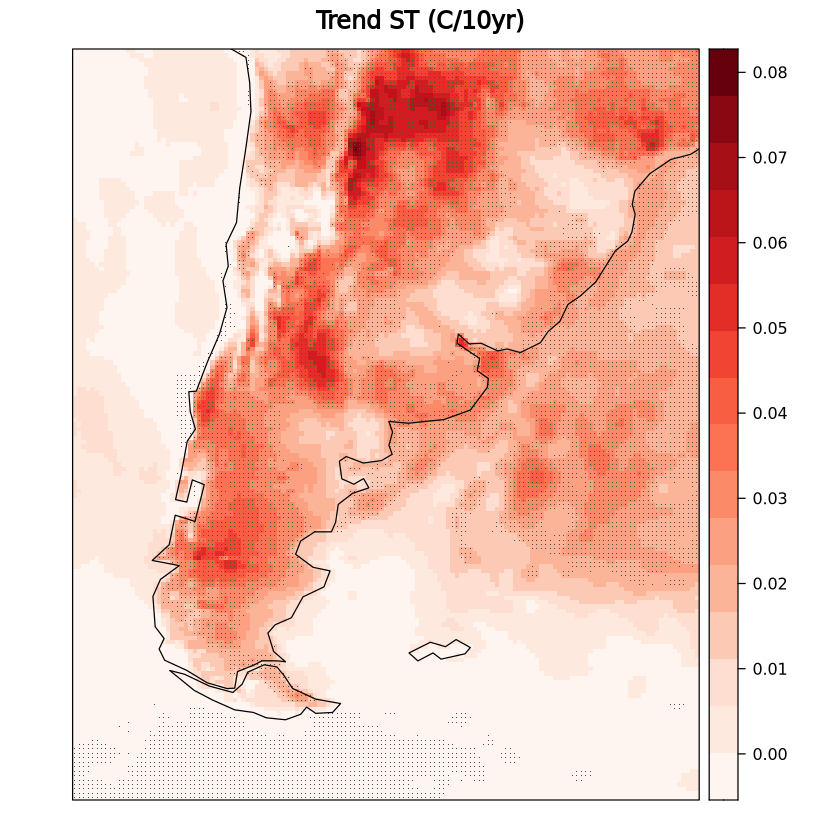

In [ ]:
#spatialPlot(gridArithmetics(trend_ST, 10, operator = "*"), backdrop.theme = "coastline")
sig.points <- map.stippling(clim = pvalueST, threshold = 0.05, condition = "LT", 
                                         pch = '.', cex = .25, col = "grey30")
 spatialPlot(gridArithmetics(trend_ST, 10, operator = "*"), backdrop.theme = "coastline", sp.layout = list(sig.points),set.min = 0,set.max = 1,color.theme = 'Reds',main = "Trend ST (C/10yr)")

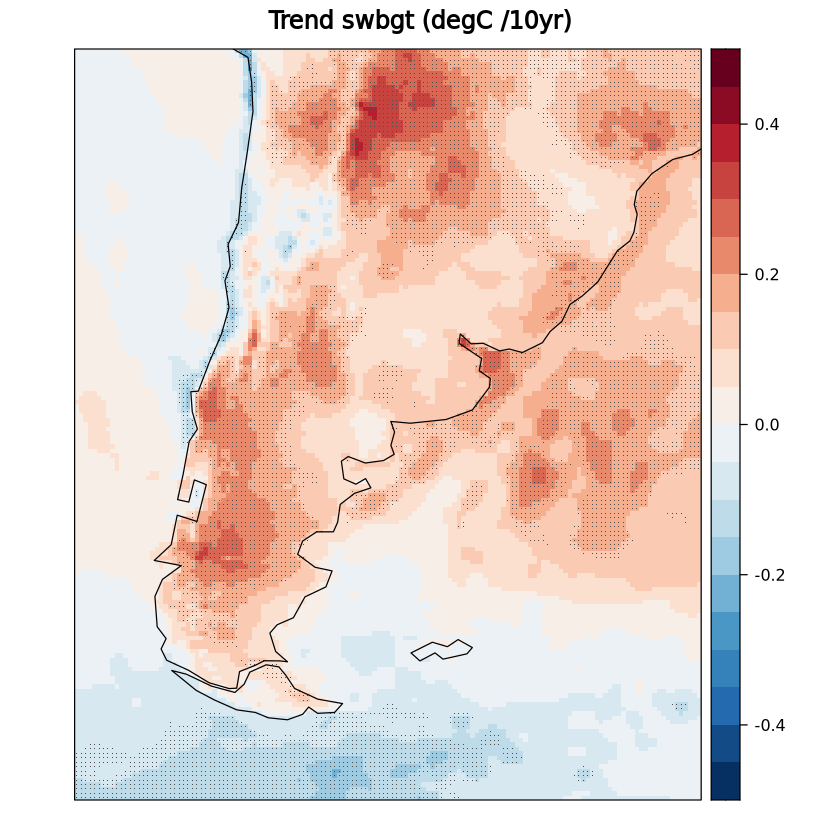

In [52]:
sig.points <- map.stippling(clim = pvalue_swbgt, threshold = 0.05, condition = "LT", 
                                         pch = '.', cex = .25, col = "grey30")
 spatialPlot(gridArithmetics(trend_swbgt, 10, operator = "*"), backdrop.theme = "coastline", sp.layout = list(sig.points),set.min = -0.5,set.max = 0.5,color.theme = 'RdBu',at=seq(-0.5,0.5,0.05),
 main = "Trend swbgt (degC /10yr)",rev.colors = T)

**Reproducibility information**

In [53]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Rocky Linux 8.10 (Green Obsidian)

Matrix products: default
BLAS/LAPACK: /nfs/home/gmeteo/balmacedar/micromamba/envs/deep-fwi/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_GB.UTF-8          LC_NUMERIC=C                 
 [3] LC_TIME=en_GB.UTF-8           LC_COLLATE=en_GB.UTF-8       
 [5] LC_MONETARY=en_GB.UTF-8       LC_MESSAGES=en_GB.UTF-8      
 [7] LC_PAPER=en_GB.UTF-8          LC_NAME=en_GB.UTF-8          
 [9] LC_ADDRESS=en_GB.UTF-8        LC_TELEPHONE=en_GB.UTF-8     
[11] LC_MEASUREMENT=en_GB.UTF-8    LC_IDENTIFICATION=en_GB.UTF-8

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] magrittr_2.0.4      convertR_0.2.1      udunits2_0.13.2.2  
 [4] trend_1.1.6         Kendall_2.2.2       RColorBrewer_1.1-3 
 [7] visualizeR_1.6.4    t